# Analisys about a employees database

First we gonna import our libs and create our dataframe

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

df_employees = pd.read_csv('../data/employees.csv')

display(df_employees.head(5))

,emp_name,department,join_date,salary,age,performance_rating,city,remote_work
0,Employee_1,Engineering,2018-01-01 00:00:00,60820.29,51.0,4.0,Pune,No
1,Employee_2,NaN,2018-01-08 20:04:01,48271.19,30.0,3.0,Delhi,No
2,Employee_3,HR,2018-01-16 16:08:02,98590.99,55.0,2.0,Mumbai,No
3,Employee_4,Marketing,2018-01-24 12:12:02,71410.54,56.0,3.0,Mumbai,No
4,Employee_5,Sales,2018-02-01 08:16:03,23547.43,43.0,4.0,Chennai,yes


now i want to see a few things about our dataset

In [76]:
display(df_employees.shape)
display(df_employees.info())
display(df_employees.describe())

(308, 8)

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_name            308 non-null    str    
 1   department          295 non-null    str    
 2   join_date           308 non-null    str    
 3   salary              290 non-null    float64
 4   age                 298 non-null    float64
 5   performance_rating  291 non-null    float64
 6   city                308 non-null    str    
 7   remote_work         281 non-null    str    
dtypes: float64(3), str(5)
memory usage: 19.4 KB


None

,salary,age,performance_rating
count,290.000000,298.000000,291.000000
mean,59624.215000,41.600671,3.584192
std,17629.028021,10.800842,1.071073
min,1657.190000,22.000000,1.000000
25%,47116.487500,33.000000,3.000000
50%,59723.160000,42.000000,4.000000
75%,71327.545000,51.000000,4.000000
max,115419.850000,59.000000,5.000000


the next step is to transform the dataframe

In [77]:
df_analisys = df_employees.drop_duplicates()
df_analisys['department'] = df_analisys['department'].fillna('Unknown')
df_analisys['remote_work'] = df_analisys['remote_work'].fillna("Unknown")
df_analisys['department'] = df_analisys['department'].str.title()
df_analisys['remote_work'] = df_analisys['remote_work'].str.title()
df_analisys['join_date'] = pd.to_datetime(df_analisys['join_date'], format="%Y-%m-%d %H:%M:%S")
display(df_analisys.sample(10))
display(df_analisys.shape)

,emp_name,department,join_date,salary,age,performance_rating,city,remote_work
147,Employee_148,Engineering,2021-02-25 21:49:58,45450.63,50.0,3.0,Delhi,No
292,Employee_293,Finance,2024-04-07 03:31:54,46261.34,48.0,NaN,Chennai,Yes
233,Employee_234,Engineering,2022-12-31 19:35:07,56022.55,46.0,4.0,Pune,No
98,Employee_99,Sales,2020-02-07 22:33:19,59779.56,52.0,4.0,Delhi,Yes
215,Employee_216,Sales,2022-08-12 18:22:53,43082.16,45.0,2.0,Mumbai,No
220,Employee_221,Marketing,2022-09-20 22:42:57,42256.93,34.0,4.0,Pune,No
70,Employee_71,Hr,2019-07-03 12:40:56,73451.28,56.0,4.0,Pune,Yes
232,Employee_233,Marketing,2022-12-23 23:31:06,57978.10,24.0,2.0,Pune,No
299,Employee_300,Sales,2024-06-01 00:00:00,30092.64,40.0,4.0,Pune,Yes
202,Employee_203,Sales,2022-05-02 21:30:42,NaN,55.0,NaN,Mumbai,No


(300, 8)

Analise dos salários por departamentos

In [78]:
df_analisys.groupby('department')['salary'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
department,,,,
Engineering,60123.532471,60184.200,22786.04,115419.85
Finance,58783.204091,61928.910,24862.42,98394.60
Hr,61699.093200,60873.390,23293.82,98590.99
Marketing,61046.397143,59428.315,1657.19,99416.45
Sales,56721.766104,56360.530,18565.42,93771.08
Unknown,67861.712500,67557.790,44496.88,89383.40


Analise dos salários baseado em trabalho remoto ou presencial

In [79]:
df_analisys.groupby('remote_work')['salary'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
remote_work,,,,
No,59069.167273,58395.84,18565.42,98590.99
Unknown,58698.166000,59095.71,34825.78,92966.26
Yes,60435.544615,60873.39,1657.19,115419.85


In [80]:
df_analisys.groupby('remote_work')['performance_rating'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
remote_work,,,,
No,3.453901,4.0,1.0,5.0
Unknown,3.391304,4.0,1.0,5.0
Yes,3.783333,4.0,1.0,5.0


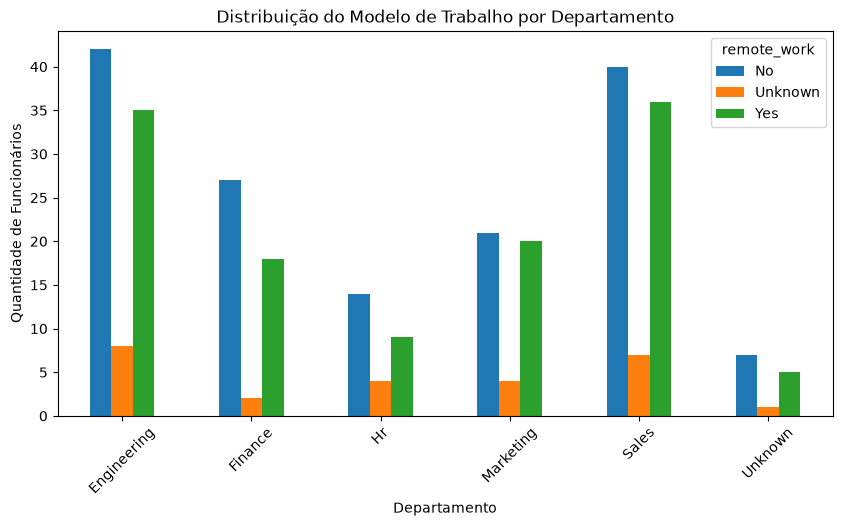

In [81]:
df_cross = pd.crosstab(df_analisys['department'], df_analisys['remote_work'])

df_cross.plot(kind='bar', figsize=(10, 5))
plt.title('Distribuição do Modelo de Trabalho por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Quantidade de Funcionários')
plt.xticks(rotation=45)
plt.show()